# Basic Visualization Tests

Reads a local Zarr store and demonstrates basic accessor methods:
spectrum extraction, light curve extraction, and plotting.

The test coordinate (RA=305.387953, Dec=+40.3297498) is used
throughout. Values should be similar across all time steps and
frequency channels.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import ovro_lwa_portal as ovro

ds = ovro.open_dataset("/lustre/claw/test6.zarr")

print(f"Dims:   {dict(ds.sizes)}")
print(f"Vars:   {list(ds.data_vars)}")
print(f"Time:   {float(ds.time.values[0]):.6f} \u2013 {float(ds.time.values[-1]):.6f} MJD  ({ds.sizes['time']} steps)")
print(f"Freq:   {float(ds.frequency.values[0])/1e6:.1f} \u2013 {float(ds.frequency.values[-1])/1e6:.1f} MHz  ({ds.sizes['frequency']} channels)")
print(f"Spatial: {ds.sizes['l']} x {ds.sizes['m']}")
print(f"WCS:    {ds.radport.has_wcs}")

Dims:   {'time': 6, 'frequency': 5, 'polarization': 1, 'beam_param': 3, 'l': 3122, 'm': 3122}
Vars:   ['BEAM', 'SKY', 'wcs_header_str']
Time:   60673.125005 – 60673.136963 MJD  (6 steps)
Freq:   66.2 – 84.6 MHz  (5 channels)
Spatial: 3122 x 3122
WCS:    True


In [2]:
RA = 305.387953
DEC = 40.3297498

print(f"Target: RA={RA:.6f}\u00b0, Dec={DEC:+.7f}\u00b0")

Target: RA=305.387953°, Dec=+40.3297498°


## Spectrum (intensity vs frequency at each time step)

Extract and display the spectrum at the target coordinate for every
time step. Values should be similar across time.

In [3]:
n_times = ds.sizes["time"]
n_freqs = ds.sizes["frequency"]
freq_mhz = ds.frequency.values / 1e6

print(f"{'time_idx':>8s}  {'MJD':>16s}  ", end="")
for f in freq_mhz:
    print(f"{f:8.1f} MHz", end="  ")
print()
print("-" * (28 + n_freqs * 12))

spectra = []
for ti in range(n_times):
    spec = ds.radport.spectrum(ra=RA, dec=DEC, time_idx=ti)
    vals = spec.values
    spectra.append(vals)
    mjd = float(ds.time.values[ti])
    print(f"{ti:>8d}  {mjd:>16.6f}  ", end="")
    for v in vals:
        print(f"{v:11.4f}", end="  ")
    print()

spectra = np.array(spectra)
print()
print(f"Mean across all (time, freq): {np.nanmean(spectra):.4f}")
print(f"Std  across all (time, freq): {np.nanstd(spectra):.4f}")

time_idx               MJD      66.2 MHz      70.8 MHz      75.4 MHz      80.0 MHz      84.6 MHz  
----------------------------------------------------------------------------------------
       0      60673.125005       3.9658       0.7935      -6.0539      -3.3526      -1.2772  
       1      60673.127326       2.1404       0.8878      -4.3486      -6.2661      -4.4598  
       2      60673.129765      -4.7841      -1.3206       2.1217      -4.1594      -6.7624  
       3      60673.132203       3.8516       5.6045      -4.3320      -6.3844      -4.0101  
       4      60673.134525      12.7518       3.6220      -1.9322      -0.4201       2.2520  
       5      60673.136963      10.8772       5.1757       4.6043       5.1006      -1.2345  

Mean across all (time, freq): 0.0884
Std  across all (time, freq): 4.9721


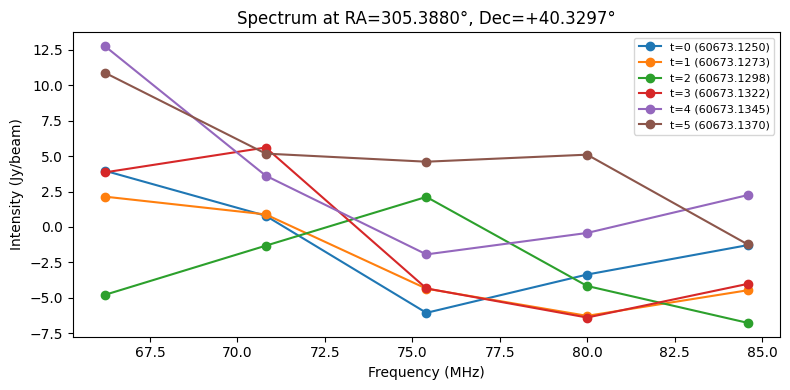

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for ti in range(n_times):
    mjd = float(ds.time.values[ti])
    ax.plot(freq_mhz, spectra[ti], "o-", label=f"t={ti} ({mjd:.4f})")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Intensity (Jy/beam)")
ax.set_title(f"Spectrum at RA={RA:.4f}\u00b0, Dec={DEC:+.4f}\u00b0")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Light curve (intensity vs time at each frequency)

Extract and display the light curve at the target coordinate for every
frequency channel. Values should be similar across frequency.

In [5]:
time_mjd = ds.time.values

print(f"{'freq_idx':>8s}  {'MHz':>8s}  ", end="")
for ti in range(n_times):
    mjd = float(time_mjd[ti])
    print(f"{mjd:>14.6f}", end="  ")
print()
print("-" * (20 + n_times * 16))

lightcurves = []
for fi in range(n_freqs):
    lc = ds.radport.light_curve(ra=RA, dec=DEC, freq_idx=fi)
    vals = lc.values
    lightcurves.append(vals)
    mhz = freq_mhz[fi]
    print(f"{fi:>8d}  {mhz:>8.1f}  ", end="")
    for v in vals:
        print(f"{v:14.4f}", end="  ")
    print()

lightcurves = np.array(lightcurves)
print()
print(f"Mean across all (freq, time): {np.nanmean(lightcurves):.4f}")
print(f"Std  across all (freq, time): {np.nanstd(lightcurves):.4f}")

freq_idx       MHz    60673.125005    60673.127326    60673.129765    60673.132203    60673.134525    60673.136963  
--------------------------------------------------------------------------------------------------------------------
Extracting tracked pixels...
       0      66.2          3.9658          2.1404         -4.7841          3.8516         12.7518         10.8772  
Extracting tracked pixels...
       1      70.8          0.7935          0.8878         -1.3206          5.6045          3.6220          5.1757  
Extracting tracked pixels...
       2      75.4         -6.0539         -4.3486          2.1217         -4.3320         -1.9322          4.6043  
Extracting tracked pixels...
       3      80.0         -3.3526         -6.2661         -4.1594         -6.3844         -0.4201          5.1006  
Extracting tracked pixels...
       4      84.6         -1.2772         -4.4598         -6.7624         -4.0101          2.2520         -1.2345  

Mean across all (freq, time): 0.088

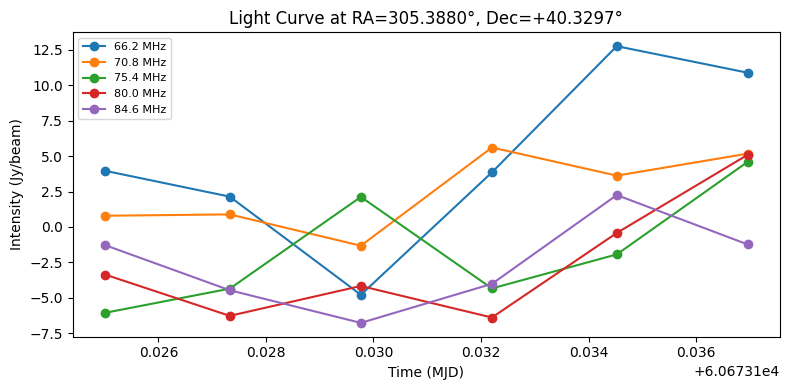

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for fi in range(n_freqs):
    ax.plot(time_mjd, lightcurves[fi], "o-", label=f"{freq_mhz[fi]:.1f} MHz")
ax.set_xlabel("Time (MJD)")
ax.set_ylabel("Intensity (Jy/beam)")
ax.set_title(f"Light Curve at RA={RA:.4f}\u00b0, Dec={DEC:+.4f}\u00b0")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Dynamic spectrum

Time-vs-frequency waterfall at the target coordinate (with source tracking).

In [7]:
dynspec = ds.radport.dynamic_spectrum(ra=RA, dec=DEC)

print(f"Dynamic spectrum shape: {dynspec.shape}  (time x frequency)")
print(f"Values:")
print(dynspec.values)
print()
print(f"Mean: {float(np.nanmean(dynspec.values)):.4f}")
print(f"Std:  {float(np.nanstd(dynspec.values)):.4f}")

Extracting tracked pixels...
Dynamic spectrum shape: (6, 5)  (time x frequency)
Values:
[[ 3.96581364  0.7934612  -6.05386543 -3.35260534 -1.27721882]
 [ 2.14042091  0.88783282 -4.34863377 -6.26610804 -4.45979166]
 [-4.78407478 -1.32062089  2.12170053 -4.15944767 -6.76239777]
 [ 3.85156941  5.60449791 -4.33195782 -6.38435411 -4.01009274]
 [12.75181675  3.62204599 -1.9322207  -0.42014503  2.2519908 ]
 [10.87724304  5.17569971  4.60429525  5.10063887 -1.23447013]]

Mean: 0.0884
Std:  4.9721


Extracting tracked pixels...


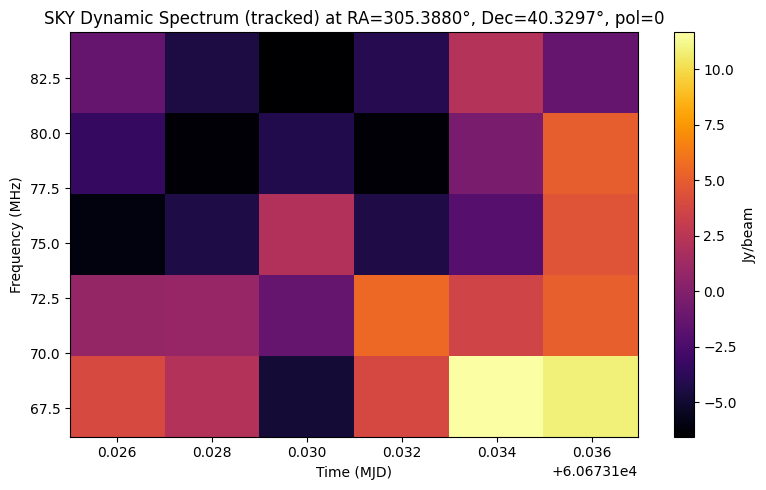

In [8]:
fig = ds.radport.plot_dynamic_spectrum(ra=RA, dec=DEC, robust=True)
plt.show()

## Accessor plot methods

Quick check that the built-in `plot_spectrum` and `plot_light_curve`
accessor methods render without error.

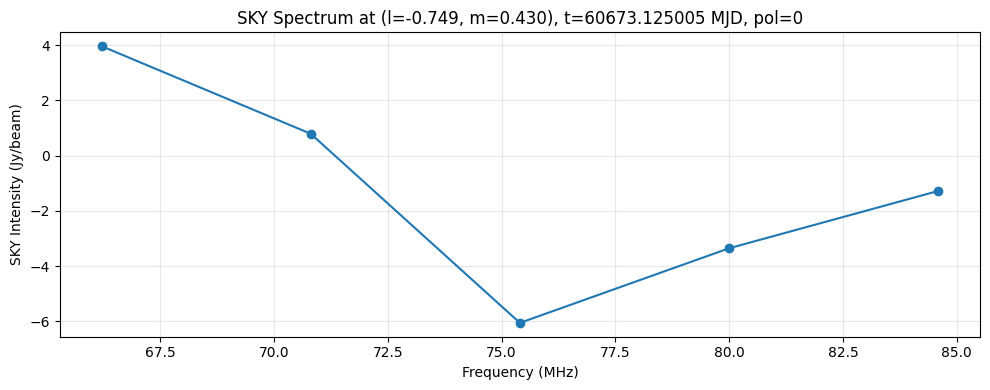

In [9]:
fig = ds.radport.plot_spectrum(ra=RA, dec=DEC, time_idx=0)
plt.show()

Extracting tracked pixels...


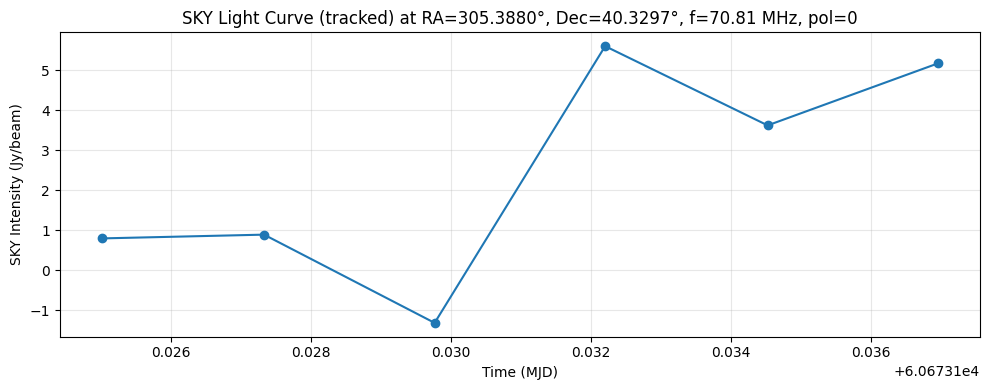

In [10]:
fig = ds.radport.plot_light_curve(ra=RA, dec=DEC, freq_mhz=73.0)
plt.show()